# Analysis of 

In [8]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
# UPDATE THIS PATH to the specific folder shown in your screenshot
folder_path = 'C:\\Users\\Minamsj\\FOMOsim\\policies\\sjovik_sund\\simulation_results\\first_test_of_maintenance_rewards' 

# Set plot style for better visuals
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [9]:
def extract_alpha_from_filename(filename):
    """
    Extracts the alpha/parameter value from filenames like:
    - sjovik_sund_alpha_0.01_results...
    - sjovik_sund_alphas1_0.003_results...
    - sjovik_sund_smaller_alphas_0.01_results...
    """
    # Regex to find a number immediately following 'alpha' (and optional chars like s, 1, _)
    match = re.search(r'alpha[a-z0-9_]*_(\d+\.?\d*)', filename)
    if match:
        return float(match.group(1))
    return None

def parse_txt_summary(filepath):
    """
    Parses the specific text file format provided to extract MILP details.
    """
    data = {
        'Objective Value': None,
        'Reward_M': None,
        'Route_Stops': 0,
        'Unique_Stations': 0
    }
    
    try:
        with open(filepath, 'r') as f:
            content = f.read()
            
            # Extract Maintenance Reward (r_M)
            r_m_match = re.search(r'Maintenance reward \(r_M\):\s*([\d\.]+)', content)
            if r_m_match:
                data['Reward_M'] = float(r_m_match.group(1))
                
            # Extract Total Objective Value
            obj_match = re.search(r'Total Objective Value:\s*([-]?\d+\.?\d*)', content)
            if obj_match:
                data['Objective Value'] = float(obj_match.group(1))
            
            # Extract Route Summary stats (from the last line usually)
            summary_match = re.search(r'Summary:\s*(\d+)\s*stops,\s*(\d+)\s*unique', content)
            if summary_match:
                data['Route_Stops'] = int(summary_match.group(1))
                data['Unique_Stations'] = int(summary_match.group(2))
                
    except Exception as e:
        print(f"Error parsing {filepath}: {e}")
        
    return data

In [10]:
all_data = []

# List all files
files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

print(f"Found {len(files)} CSV files to process...")

for csv_file in files:
    # Construct paths
    csv_path = os.path.join(folder_path, csv_file)
    
    # Infer the text file name. 
    # Usually: 'filename.csv' -> 'filename_summary_seed_1.txt' 
    # Based on your image: '...results.csv' -> '...results_summary_seed_1.txt'
    txt_file = csv_file.replace('.csv', '_summary_seed_1.txt')
    txt_path = os.path.join(folder_path, txt_file)
    
    # 1. Parse CSV
    try:
        df_temp = pd.read_csv(csv_path)
        # Take the first row (assuming one seed per file based on your example)
        row_data = df_temp.iloc[0].to_dict()
    except Exception as e:
        print(f"Skipping {csv_file} due to CSV error: {e}")
        continue

    # 2. Parse TXT (if it exists)
    txt_data = {}
    if os.path.exists(txt_path):
        txt_data = parse_txt_summary(txt_path)
    
    # 3. Extract Alpha from filename
    alpha_val = extract_alpha_from_filename(csv_file)
    
    # 4. Merge all info
    combined_entry = {**row_data, **txt_data}
    combined_entry['Filename_Alpha'] = alpha_val
    combined_entry['Source_File'] = csv_file
    
    all_data.append(combined_entry)

# Create Master DataFrame
df = pd.DataFrame(all_data)

# Sort by Alpha for cleaner plotting
if 'Filename_Alpha' in df.columns:
    df.sort_values('Filename_Alpha', inplace=True)

# Display first few rows
print(f"Successfully loaded {len(df)} simulations.")
df.head()

Found 14 CSV files to process...
Successfully loaded 14 simulations.


,Seed,Duration (hours),Total Runtime (s),Failed Events,Starvations,Bike Starvations,Long Congestions,Short Congestions,Total Trips,Bike Departures,...,Bike Pickups,Maintenance Time (minutes),Maintenance Violations,Maintenance Starvations,Objective Value,Reward_M,Route_Stops,Unique_Stations,Filename_Alpha,Source_File
11,1.0,24.0,1860.0,348.0,210.0,43.0,138.0,85.0,3206.0,2996.0,...,117.0,36.659434,85.0,167.0,156.0202,0.003,66,30,0.001,sjovik_sund_smaller_alphas_0.001_results.csv
0,1.0,24.0,1860.0,319.0,251.0,113.0,68.0,110.0,3270.0,3019.0,...,124.0,42.673210,94.0,138.0,142.9913,0.003,68,30,0.003,sjovik_sund_alphas1_0.003_results.csv
1,1.0,24.0,1860.0,367.0,274.0,147.0,93.0,133.0,3348.0,3074.0,...,119.0,43.987479,98.0,127.0,164.1043,0.005,69,31,0.005,sjovik_sund_alphas1_0.005_results.csv
2,1.0,24.0,1860.0,303.0,197.0,99.0,106.0,114.0,3216.0,3019.0,...,125.0,46.294522,99.0,98.0,135.0715,0.007,68,32,0.007,sjovik_sund_alphas1_0.007_results.csv
12,1.0,24.0,1860.0,286.0,166.0,41.0,120.0,120.0,3236.0,3070.0,...,126.0,29.401639,100.0,125.0,127.1190,0.010,70,35,0.010,sjovik_sund_smaller_alphas_0.01_results.csv


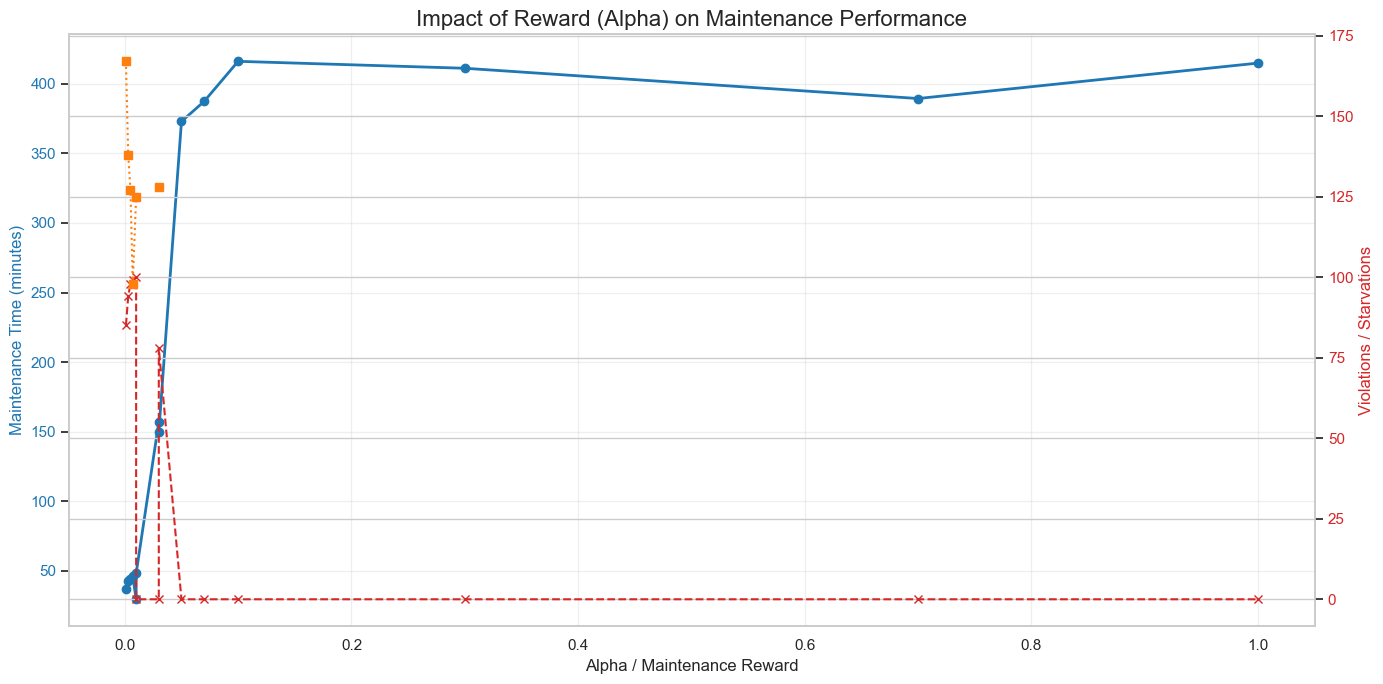

In [11]:
# Create a dual-axis plot
fig, ax1 = plt.subplots(figsize=(14, 7))

x_col = 'Filename_Alpha' 

# Plot Maintenance Time (Left Axis)
color = 'tab:blue'
ax1.set_xlabel('Alpha / Maintenance Reward')
ax1.set_ylabel('Maintenance Time (minutes)', color=color)
ax1.plot(df[x_col], df['Maintenance Time (minutes)'], marker='o', color=color, linewidth=2, label='Maintenance Time')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Plot Maintenance Violations or Starvations (Right Axis)
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Violations / Starvations', color=color)
ax2.plot(df[x_col], df['Maintenance Violations'], marker='x', linestyle='--', color=color, label='Violations')
ax2.plot(df[x_col], df['Maintenance Starvations'], marker='s', linestyle=':', color='tab:orange', label='Maint. Starvations')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Impact of Reward (Alpha) on Maintenance Performance', fontsize=16)
fig.tight_layout()  
plt.show()

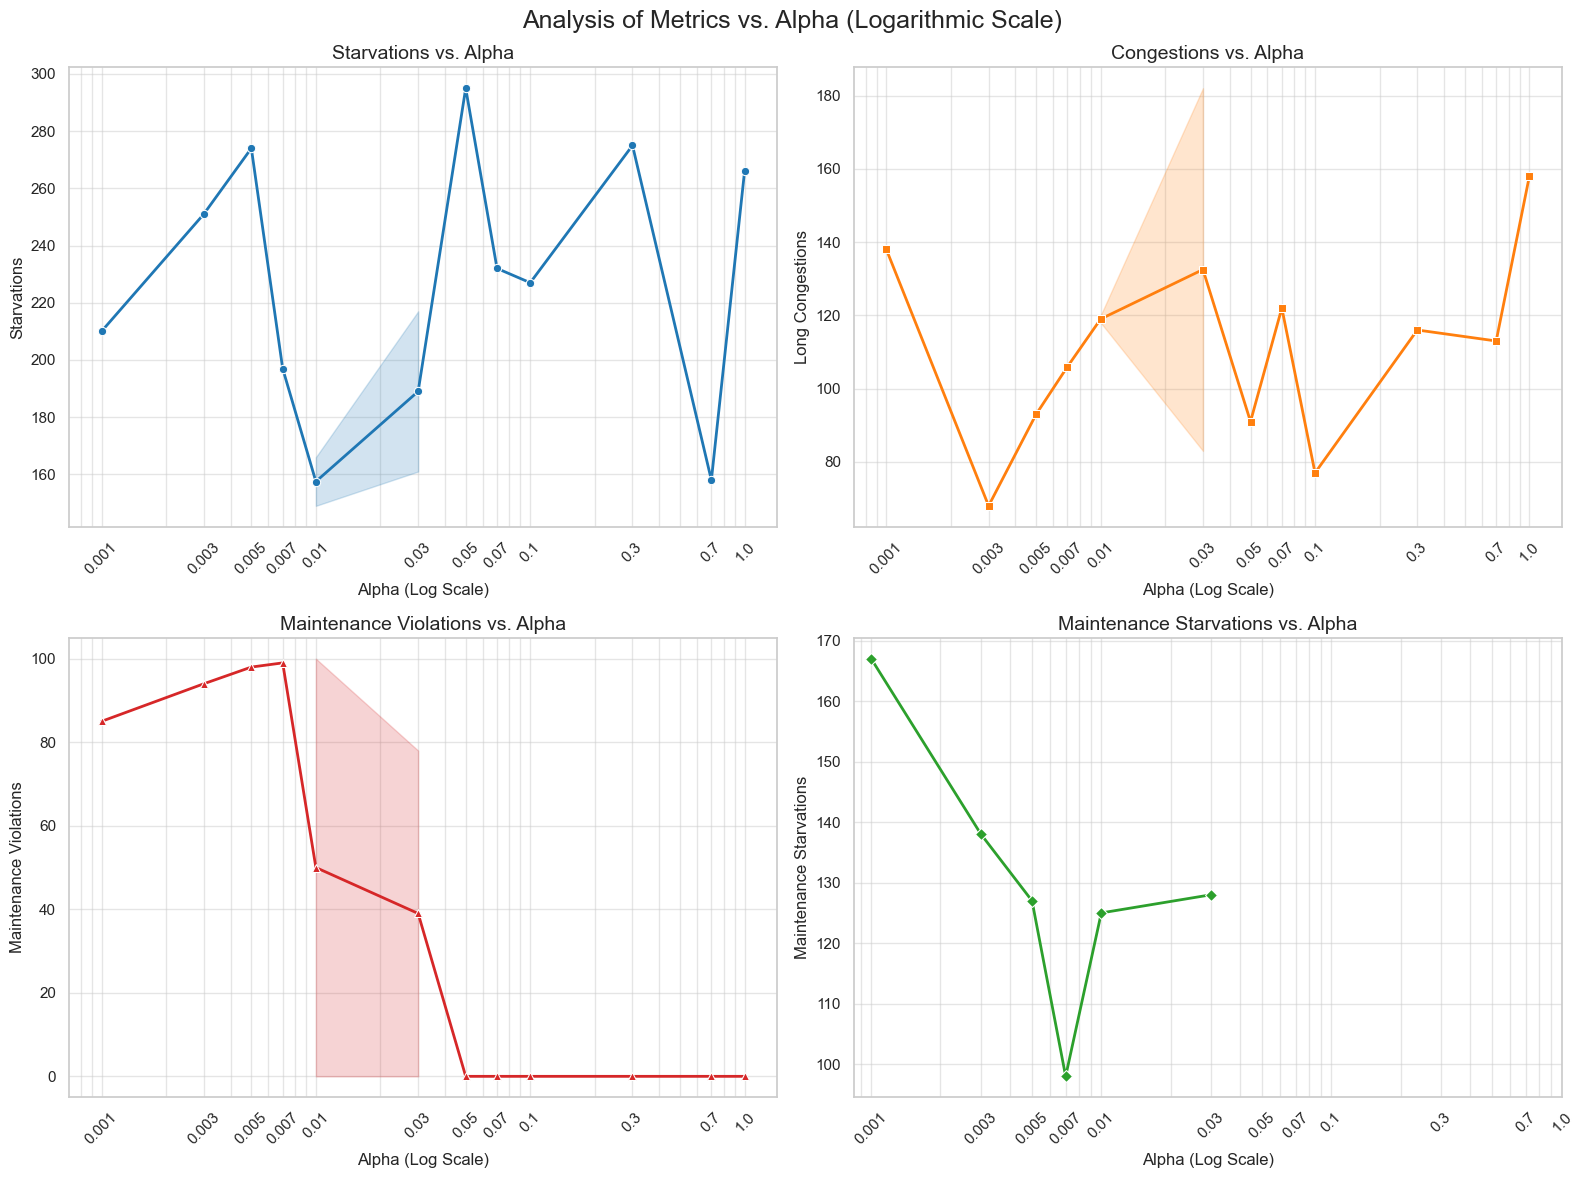

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Set plot style
sns.set_theme(style="whitegrid")

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Analysis of Metrics vs. Alpha (Logarithmic Scale)', fontsize=18)

# Get unique alpha values for custom ticks
unique_alphas = sorted(df['Filename_Alpha'].unique())

# Helper function to plot with consistent log-scale formatting
def create_log_plot(ax, y_col, title, color, marker):
    sns.lineplot(
        ax=ax, 
        data=df, 
        x='Filename_Alpha', 
        y=y_col, 
        marker=marker, 
        color=color, 
        linewidth=2
    )
    
    ax.set_title(title, fontsize=14)
    ax.set_ylabel(y_col)
    ax.set_xlabel('Alpha (Log Scale)')
    
    # --- KEY CHANGE: Log Scale & Granular Ticks ---
    ax.set_xscale('log')
    
    # Force the plot to show a tick for EVERY alpha value you have
    ax.set_xticks(unique_alphas)
    
    # Format labels as standard numbers (not scientific notation like 10^-2)
    ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
    ax.set_xticklabels(unique_alphas, rotation=45)
    
    # Add a grid for easier reading
    ax.grid(True, which="both", ls="-", alpha=0.5)

# 1. Starvations
create_log_plot(axes[0, 0], 'Starvations', 'Starvations vs. Alpha', 'tab:blue', 'o')

# 2. Congestions
create_log_plot(axes[0, 1], 'Long Congestions', 'Congestions vs. Alpha', 'tab:orange', 's')

# 3. Maintenance Violations
create_log_plot(axes[1, 0], 'Maintenance Violations', 'Maintenance Violations vs. Alpha', 'tab:red', '^')

# 4. Maintenance Starvations
create_log_plot(axes[1, 1], 'Maintenance Starvations', 'Maintenance Starvations vs. Alpha', 'tab:green', 'D')

plt.tight_layout()
plt.show()